In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load Data
df = pd.read_csv('Datasets/powerplant_data.csv')
df.head(3)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76


- AT = Temperature
- V  = Vaccum
- AP = Pressure
- RH = Humidity
- PE = Produced Energy

In [3]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["PE"])
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(7654, 4)

In [4]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Convert to Tensor
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [6]:
# Load Tensor Data
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
# ANN Model
import torch.nn as nn

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(in_features=X_train.shape[1], out_features=6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(in_features=6, out_features=6),
            nn.ReLU(),
    
            # Output layer
            nn.Linear(in_features=6, out_features=1)
        )

    def forward(self, x):
        return self.model(x)

model = ANN()

In [8]:
# Loss, Optimizer
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [9]:
# Train Model
epochs = 50
train_losses = []
valid_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    # xb & yb are features & labels of 1 batch
    for xb, yb in train_loader:
        optimizer.zero_grad()
        
        # Forward Propagation
        outputs = model(xb)

        # Loss computation
        loss = criterion(outputs, yb)
        running_loss += loss.item()

        # Backward Propagation
        loss.backward()

        # Parameter update
        optimizer.step()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():  # no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    # Save model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "Outputs/02_best_model.pt") # .pt or .pth

epoch 1/50 ==> training loss = 206505.45625 & val loss = 204500.921875
epoch 2/50 ==> training loss = 197421.38776041666 & val loss = 185606.734375
epoch 3/50 ==> training loss = 164892.15553385418 & val loss = 140152.296875
epoch 4/50 ==> training loss = 111822.49973958333 & val loss = 84430.0859375
epoch 5/50 ==> training loss = 62561.51909179687 & val loss = 45285.7109375
epoch 6/50 ==> training loss = 35001.55270182292 & val loss = 27617.71875
epoch 7/50 ==> training loss = 23292.22539876302 & val loss = 19945.326171875
epoch 8/50 ==> training loss = 17703.605358886718 & val loss = 15612.984375
epoch 9/50 ==> training loss = 13986.98769124349 & val loss = 12245.6611328125
epoch 10/50 ==> training loss = 10813.552274576823 & val loss = 9194.3740234375
epoch 11/50 ==> training loss = 7911.59580078125 & val loss = 6488.3818359375
epoch 12/50 ==> training loss = 5413.747234598795 & val loss = 4350.9140625
epoch 13/50 ==> training loss = 3593.3235178629557 & val loss = 2880.8271484375
e

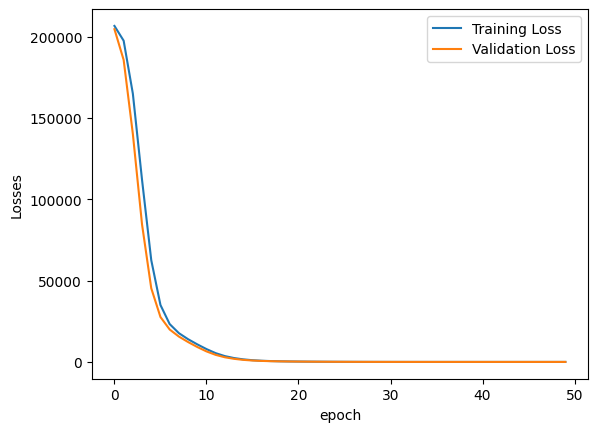

In [10]:
# Plot
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")
plt.xlabel("epoch")
plt.ylabel("Losses")
plt.legend()

In [11]:
# Loading Best Model
model